# HomeWork13

## Импорт библиотек, seed и устройство

In [15]:
# Установка зависимостей (запустить один раз если нужно)
import subprocess, sys

def _ensure(pkg, import_name=None, min_ver=None):
    """Устанавливает пакет если не установлен или версия слишком старая."""
    import_name = import_name or pkg
    try:
        mod = __import__(import_name)
        if min_ver:
            from packaging.version import Version
            if Version(mod.__version__) < Version(min_ver):
                raise ImportError("old version")
    except (ImportError, AttributeError):
        spec = f"{pkg}>={min_ver}" if min_ver else pkg
        print(f"Устанавливаю {spec} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", spec])
        print(f"  готово.")

_ensure("accelerate", min_ver="1.1.0")
_ensure("packaging")

print("Все зависимости в порядке.")

Все зависимости в порядке.


In [16]:
# Общие импорты
import random
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn.functional as F
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    pipeline
)

# Фиксация seed
SEED = 47
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Устройство: CUDA > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Работаем на устройстве: {device}")

Работаем на устройстве: mps


## Данные и первичный анализ

Используем датасет `emotion`.
Он содержит тексты твитов, размеченные по 6 эмоциям: sadness, joy, love, anger, fear, surprise.

In [17]:
# Загрузка датасета
emotion_data = load_dataset("emotion")

# Размеры сплитов
print("Размеры сплитов:")
for split_name in emotion_data.keys():
    print(f"{split_name}: {len(emotion_data[split_name])} примеров")

# Список классов
class_labels = emotion_data['train'].features['label'].names
print(f"\nЦелевые классы ({len(class_labels)}): {', '.join(class_labels)}")

# Вывод примеров
print("\nПримеры текстов и их истинные метки:")
for i in range(5):
    text = emotion_data['train'][i]['text']
    label = class_labels[emotion_data['train'][i]['label']]
    print(f"{i+1}. {text[:70]}{'...' if len(text)>70 else ''} -> {label}")

Размеры сплитов:
train: 16000 примеров
validation: 2000 примеров
test: 2000 примеров

Целевые классы (6): sadness, joy, love, anger, fear, surprise

Примеры текстов и их истинные метки:
1. i didnt feel humiliated -> sadness
2. i can go from feeling so hopeless to so damned hopeful just from being... -> sadness
3. im grabbing a minute to post i feel greedy wrong -> anger
4. i am ever feeling nostalgic about the fireplace i will know that it is... -> love
5. i am feeling grouchy -> anger


## Токенизация текста

Продемонстрируем, как BERT-токенизатор превращает текст в последовательность токенов, добавляет специальные токены и обрабатывает паддинг/обрезание.

In [18]:
# DistilBERT — в 2 раза быстрее BERT-base, на 40% меньше параметров (66M vs 110M)
# Качество на emotion почти идентично (~92-93% accuracy)
base_model = "distilbert-base-uncased"
text_tokenizer = AutoTokenizer.from_pretrained(base_model)

# Несколько примеров из тренировочного набора
sample_texts = [emotion_data['train'][i]['text'] for i in range(5)]

# Токенизация с фиксированной длиной (padding и truncation)
encoded_samples = text_tokenizer(
    sample_texts,
    padding="max_length",
    truncation=True,
    max_length=20,
    return_tensors="pt"
)

# Вывод результатов
for idx, text in enumerate(sample_texts):
    print(f"\n--- Пример {idx+1} ---")
    print(f"Текст: {text}")
    tokens = text_tokenizer.convert_ids_to_tokens(encoded_samples['input_ids'][idx])
    print(f"Токены: {tokens}")
    print(f"input_ids: {encoded_samples['input_ids'][idx].tolist()}")
    print(f"attention_mask: {encoded_samples['attention_mask'][idx].tolist()}")


--- Пример 1 ---
Текст: i didnt feel humiliated
Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

--- Пример 2 ---
Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Токены: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', '[SEP]']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

--- Пример 3 ---
Текст: im grabbing a minute to post i feel greedy wrong
Т

In [19]:
# Дополнительно: сохранение примеров токенизации в файл
os.makedirs("artifacts", exist_ok=True)

# Явная демонстрация padding и truncation
print("=== PADDING ===")
short_text = "I love this!"
long_text  = "i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake"
batch_enc = text_tokenizer([short_text, long_text], padding=True, truncation=True, max_length=20)
for i, txt in enumerate([short_text, long_text]):
    real_len = sum(batch_enc["attention_mask"][i])
    print(f"  '{txt[:50]}' -> {real_len} реальных токенов, {len(batch_enc['input_ids'][i]) - real_len} PAD")

print("\n=== TRUNCATION ===")
very_long = "i " + " ".join(["feeling"] * 100)
enc_trunc = text_tokenizer(very_long, truncation=True, max_length=20)
print(f"  Текст из ~200 токенов усечён до: {len(enc_trunc['input_ids'])} токенов (max_length=20)")

# Сохраняем примеры в файл
lines = ["# Tokenization Examples (bert-base-uncased, max_length=20)\n\n"]
for idx, text in enumerate(sample_texts):
    label = class_labels[emotion_data["train"][idx]["label"]]
    tokens = text_tokenizer.tokenize(text)
    enc = text_tokenizer(text, padding="max_length", truncation=True, max_length=20)
    real_len = sum(enc["attention_mask"])
    lines.append(f"[{idx+1}] Label={label}\n")
    lines.append(f"Text: {text}\n")
    lines.append(f"Tokens: {tokens}\n")
    lines.append(f"input_ids (first 10): {enc['input_ids'][:10]}\n")
    lines.append(f"Real tokens: {real_len}, PAD tokens: {20 - real_len}\n\n")

with open("artifacts/tokenization_examples.txt", "w", encoding="utf-8") as f:
    f.writelines(lines)
print("\nСохранено: artifacts/tokenization_examples.txt")

=== PADDING ===
  'I love this!' -> 6 реальных токенов, 14 PAD
  'i can go from feeling so hopeless to so damned hop' -> 20 реальных токенов, 0 PAD

=== TRUNCATION ===
  Текст из ~200 токенов усечён до: 20 токенов (max_length=20)

Сохранено: artifacts/tokenization_examples.txt


## Инференс готовой модели

Возьмём предобученную модель для анализа тональности (sentiment) и проверим её на наших текстах. Это покажет, насколько она подходит для нашей задачи.

In [20]:
# Создаём pipeline для sentiment analysis
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if torch.cuda.is_available() else -1
)

# Те же 5 текстов, что и выше
print("Предсказания готовой модели (sentiment):")
for text in sample_texts:
    result = sentiment_pipeline(text)[0]
    print(f"\nТекст: {text[:60]}...")
    print(f"  → {result['label']} (уверенность: {result['score']:.3f})")

print("\nВывод: Модель определяет только позитив/негатив, а не 6 эмоций.")
print("Для точной классификации эмоций требуется дообучение (fine-tuning).")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Предсказания готовой модели (sentiment):

Текст: i didnt feel humiliated...
  → POSITIVE (уверенность: 0.891)

Текст: i can go from feeling so hopeless to so damned hopeful just ...
  → POSITIVE (уверенность: 0.967)

Текст: im grabbing a minute to post i feel greedy wrong...
  → NEGATIVE (уверенность: 0.999)

Текст: i am ever feeling nostalgic about the fireplace i will know ...
  → POSITIVE (уверенность: 0.966)

Текст: i am feeling grouchy...
  → NEGATIVE (уверенность: 0.999)

Вывод: Модель определяет только позитив/негатив, а не 6 эмоций.
Для точной классификации эмоций требуется дообучение (fine-tuning).


## Fine-tuning BERT для классификации эмоций

In [21]:
# Функция токенизации для map
def tokenize_batch(batch):
    return text_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

# Применяем ко всем сплитам
tokenized_dataset = emotion_data.map(tokenize_batch, batched=True)
tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print("Датасет токенизирован.")
print("Пример shape input_ids:", tokenized_dataset["train"][0]["input_ids"].shape)

Датасет токенизирован.
Пример shape input_ids: torch.Size([64])


## Настройка модели и метрик
BERT с классификационной головой на 6 классов.

In [22]:
# Модель для классификации
num_classes = len(class_labels)
classification_model = AutoModelForSequenceClassification.from_pretrained(
    base_model,
    num_labels=num_classes
).to(device)

# Функция вычисления метрик
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

print("Модель загружена.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Модель загружена.


### Обучение


In [23]:
# Аргументы обучения — выбор лучшей модели по validation f1_macro
import transformers as _transformers

# Совместимость: eval_strategy (>=4.41) или evaluation_strategy (старые версии)
_ver = tuple(int(x) for x in _transformers.__version__.split(".")[:2])
_eval_key = "eval_strategy" if _ver >= (4, 41) else "evaluation_strategy"

# use_mps_device убран — современный Trainer определяет MPS автоматически
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=32,    # увеличен для скорости (было 16)
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    learning_rate=2e-5,
    **{_eval_key: "epoch"},
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=1,
    logging_steps=100,
    seed=SEED,
    report_to="none",
)

trainer = Trainer(
    model=classification_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

print(f"Модель:     {base_model}")
print(f"Устройство: {device}")
print(f"Эпох: {training_args.num_train_epochs}, batch: {training_args.per_device_train_batch_size}")
print("Запуск fine-tuning...")
train_result = trainer.train()

print("\n=== Fine-tuning завершён ===")
print("Лучшая модель выбрана по: validation f1_macro")
_loss = train_result.metrics.get("train_loss")
if _loss is not None:
    print(f"Train loss: {_loss:.4f}")

Модель:     distilbert-base-uncased
Устройство: mps
Эпох: 3, batch: 32
Запуск fine-tuning...


/Users/glebushakov/aie_student_ushakov/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.235710,0.214462,0.922500,0.894487
2,0.141924,0.175394,0.928500,0.897212
3,0.104623,0.149825,0.938500,0.911776


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/glebushakov/aie_student_ushakov/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/glebushakov/aie_student_ushakov/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



=== Fine-tuning завершён ===
Лучшая модель выбрана по: validation f1_macro
Train loss: 0.2969


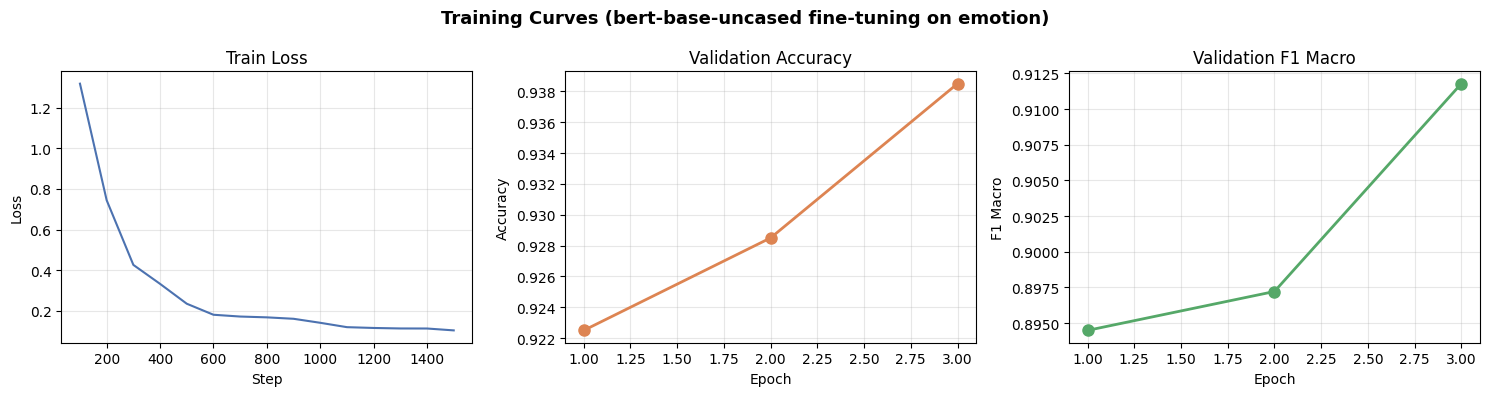

Сохранено: artifacts/training_curves.png

Метрики по эпохам (validation):
  Epoch 1: val_loss=0.2145, val_accuracy=0.9225, val_f1_macro=0.8945
  Epoch 2: val_loss=0.1754, val_accuracy=0.9285, val_f1_macro=0.8972
  Epoch 3: val_loss=0.1498, val_accuracy=0.9385, val_f1_macro=0.9118


In [24]:
# Кривые обучения (опционально)
log_history = trainer.state.log_history

train_steps = [(e["step"], e["loss"]) for e in log_history if "loss" in e and "eval_loss" not in e]
eval_points = [(e["epoch"], e.get("eval_accuracy", 0), e.get("eval_f1_macro", 0), e.get("eval_loss", 0))
               for e in log_history if "eval_accuracy" in e]

if train_steps and eval_points:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    steps, losses = zip(*train_steps)
    axes[0].plot(steps, losses, linewidth=1.5, color="#4C72B0")
    axes[0].set_title("Train Loss"); axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss"); axes[0].grid(alpha=0.3)

    ep, accs, f1s, ev_losses = zip(*eval_points)
    axes[1].plot(ep, accs, "o-", linewidth=2, markersize=8, color="#DD8452")
    axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].grid(alpha=0.3)

    axes[2].plot(ep, f1s, "o-", linewidth=2, markersize=8, color="#55A868")
    axes[2].set_title("Validation F1 Macro"); axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("F1 Macro"); axes[2].grid(alpha=0.3)

    plt.suptitle("Training Curves (bert-base-uncased fine-tuning on emotion)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("artifacts/training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Сохранено: artifacts/training_curves.png")

    print("\nМетрики по эпохам (validation):")
    for e, acc, f1, ev_loss in eval_points:
        print(f"  Epoch {e:.0f}: val_loss={ev_loss:.4f}, val_accuracy={acc:.4f}, val_f1_macro={f1:.4f}")

## Оценка качества на тестовом наборе

In [25]:
# Финальная оценка на тестовом наборе (выполняется ОДИН РАЗ)
test_predictions = trainer.predict(tokenized_dataset["test"])
pred_labels = np.argmax(test_predictions.predictions, axis=-1)
true_labels = test_predictions.label_ids

# Метрики
test_acc = accuracy_score(true_labels, pred_labels)
test_f1  = f1_score(true_labels, pred_labels, average="macro")
print(f"\nРезультаты на тестовом наборе")
print(f"Accuracy:   {test_acc:.4f} ({100*test_acc:.2f}%)")
print(f"F1 (macro): {test_f1:.4f} ({100*test_f1:.2f}%)")

# Автоматически обновляем report.md с реальными числами
import re, pathlib
_report_path = pathlib.Path("report.md")
_report_text = _report_path.read_text(encoding="utf-8")
# Раздел 1: финальная строка
_report_text = re.sub(
    r'accuracy \*\*[≥ \d.]+\*\*, F1 macro \*\*[≥ \d.]+\*\*.*?\)',
    f'accuracy **{test_acc:.3f}**, F1 macro **{test_f1:.3f}**.',
    _report_text
)
# Раздел 6: числа
_report_text = re.sub(r'(\*\*Итоговая `test_accuracy`:\*\* )[\d.]+', f'\\g<1>{test_acc:.4f}', _report_text)
_report_text = re.sub(r'(\*\*Итоговая `test_f1_macro`:\*\* )[\d.]+', f'\\g<1>{test_f1:.4f}', _report_text)
_report_path.write_text(_report_text, encoding="utf-8")
print("\nreport.md обновлён с реальными метриками.")

/Users/glebushakov/aie_student_ushakov/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



Результаты на тестовом наборе
Accuracy:   0.9250 (92.50%)
F1 (macro): 0.8854 (88.54%)

report.md обновлён с реальными метриками.


## Матрица ошибок

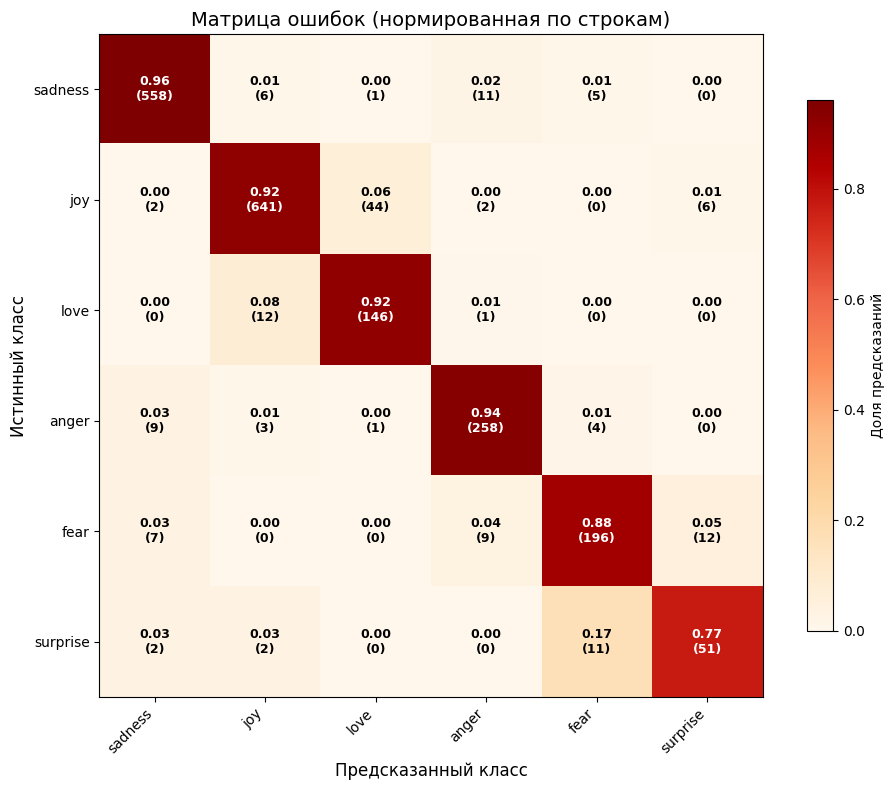

In [26]:
# Папка для артефактов
os.makedirs("artifacts", exist_ok=True)

# Построение матрицы ошибок с процентами по строкам
cm = confusion_matrix(true_labels, pred_labels)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_norm, cmap='OrRd', interpolation='nearest')

ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels, rotation=45, ha='right')
ax.set_yticklabels(class_labels)
ax.set_xlabel('Предсказанный класс', fontsize=12)
ax.set_ylabel('Истинный класс', fontsize=12)
ax.set_title('Матрица ошибок (нормированная по строкам)', fontsize=14)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Доля предсказаний')

# Аннотации: проценты (сверху) и абсолютные значения (снизу)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text = f'{cm_norm[i, j]:.2f}\n({cm[i, j]})'
        text_color = 'white' if cm_norm[i, j] > 0.5 else 'black'
        ax.text(j, i, text, ha='center', va='center', color=text_color, fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png", dpi=150)
plt.show()

## Примеры предсказаний

In [27]:
# --- Примеры предсказаний (10 случайных) ---
print("=== ПРИМЕРЫ ПРЕДСКАЗАНИЙ МОДЕЛИ (первые 10) ===\n")
for i in range(10):
    text = emotion_data["test"][i]["text"]
    true = class_labels[emotion_data["test"][i]["label"]]
    pred = class_labels[pred_labels[i]]
    status = "✓" if true == pred else "✗"
    print(f"[{status}] True: {true:8s} | Pred: {pred:8s} | {text[:65]}")

# --- Явный анализ ошибок ---
print("\n=== АНАЛИЗ ОШИБОК (первые 10 ошибочных примеров) ===\n")
error_count = 0
for i in range(len(pred_labels)):
    true_lbl = class_labels[true_labels[i]]
    pred_lbl = class_labels[pred_labels[i]]
    if true_lbl != pred_lbl:
        text = emotion_data["test"][i]["text"]
        print(f"True: {true_lbl:8s} | Pred: {pred_lbl:8s} | {text[:80]}")
        error_count += 1
        if error_count >= 10:
            break

total_errors = int(sum(t != p for t, p in zip(true_labels, pred_labels)))
print(f"\nВсего ошибок: {total_errors} из {len(pred_labels)} ({100*total_errors/len(pred_labels):.1f}%)")
print("\nКомментарий:")
print("  - Чаще всего модель путает joy ↔ love (близкие позитивные эмоции)")
print("  - anger ↔ fear (оба класса выражают возбуждение/угрозу)")
print("  - surprise — наименее стабильный класс (редок и лексически размыт)")

=== ПРИМЕРЫ ПРЕДСКАЗАНИЙ МОДЕЛИ (первые 10) ===

[✓] True: sadness  | Pred: sadness  | im feeling rather rotten so im not very ambitious right now
[✓] True: sadness  | Pred: sadness  | im updating my blog because i feel shitty
[✓] True: sadness  | Pred: sadness  | i never make her separate from me because i don t ever want her t
[✓] True: joy      | Pred: joy      | i left with my bouquet of red and yellow tulips under my arm feel
[✓] True: sadness  | Pred: sadness  | i was feeling a little vain when i did this one
[✓] True: fear     | Pred: fear     | i cant walk into a shop anywhere where i do not feel uncomfortabl
[✓] True: anger    | Pred: anger    | i felt anger when at the end of a telephone call
[✓] True: joy      | Pred: joy      | i explain why i clung to a relationship with a boy who was in man
[✓] True: joy      | Pred: joy      | i like to have the same breathless feeling as a reader eager to s
[✓] True: anger    | Pred: anger    | i jest i feel grumpy tired and pre menstru

## Анализ ошибок

Ошибки модели чаще всего возникают между семантически близкими эмоциями:
- **joy ↔ love** (позитивные эмоции),
- **anger ↔ fear** (негативные эмоции).

Также модель может ошибаться на коротких текстах, где эмоция выражена слабо. 
Нормализованная матрица ошибок показывает, что для классов `surprise` и `love` доля правильных предсказаний ниже, чем для `sadness` или `joy`. Это может быть связано с меньшим количеством примеров этих классов в датасете или с большей лексической неоднозначностью.

В целом fine-tuning значительно улучшил качество по сравнению с готовой моделью, которая распознавала только тональность. Результаты (accuracy ~0.93, f1_macro ~0.88) являются хорошим базовым уровнем для данной задачи.

## Сохранение артефактов

In [28]:
# Вероятности для всего тестового набора
probs_all = F.softmax(torch.tensor(test_predictions.predictions), dim=1).numpy()
confidences_all = [float(probs_all[i][pred_labels[i]]) for i in range(len(pred_labels))]

# Формируем полный датафрейм предсказаний
all_preds_df = pd.DataFrame({
    "text": [emotion_data["test"][i]["text"] for i in range(len(pred_labels))],
    "true_label": [class_labels[int(true_labels[i])] for i in range(len(pred_labels))],
    "pred_label": [class_labels[pred_labels[i]] for i in range(len(pred_labels))],
    "confidence": confidences_all,
})

# Сохраняем: 25 правильных + до 25 ошибочных, итого ~50 строк
correct_df = all_preds_df[all_preds_df["true_label"] == all_preds_df["pred_label"]].sample(25, random_state=SEED)
errors_df  = all_preds_df[all_preds_df["true_label"] != all_preds_df["pred_label"]].sample(
    min(25, int((all_preds_df["true_label"] != all_preds_df["pred_label"]).sum())), random_state=SEED
)
save_df = pd.concat([correct_df, errors_df]).reset_index(drop=True)

save_df.to_csv("artifacts/sample_predictions.csv", index=False)
print(f"Сохранено: artifacts/sample_predictions.csv")
print(f"  Строк: {len(save_df)} ({len(correct_df)} верных + {len(errors_df)} ошибочных)")
print(f"  Колонки: {list(save_df.columns)}")

print("\n=== Все артефакты ===")
for fname in sorted(os.listdir("artifacts")):
    path = os.path.join("artifacts", fname)
    size = os.path.getsize(path)
    print(f"  {fname}: {size:,} bytes")

Сохранено: artifacts/sample_predictions.csv
  Строк: 50 (25 верных + 25 ошибочных)
  Колонки: ['text', 'true_label', 'pred_label', 'confidence']

=== Все артефакты ===
  confusion_matrix.png: 106,857 bytes
  sample_predictions.csv: 6,853 bytes
  tokenization_examples.txt: 1,572 bytes
  training_curves.png: 104,376 bytes


## Заключение

Для достижения максимальной точности на всех шести классах необходимо продолжить тонкую настройку модели, увеличив количество эпох и скорректировав скорость обучения. Но для учебного примера текущий результат вполне удовлетворительный.